# Final Exam (Assignment) - Deep Learning for NLP

## Q1. The need and tasks of text pre-processing (20 Marks)

Answer the following questions:

1. Explain the importance of text pre-processing in Natural Language Processing (NLP).
2. Explain the following text pre-processing techniques with suitable examples:
    - Tokenization
    - Stopword Removal
    - Stemming
3. Differentiate between stemming and lemmatization with examples.
4. Explain how tokenization and stopword removal help in sentiment analysis or text classification tasks.


## Q2. Text Classification using Support Vector Machines (40 marks)

**Business Context:**

Businesses analyze customer reviews to understand user sentiment and improve products or services. Sentiment analysis helps companies quickly identify positive and negative feedback at scale. This enables better decision-making, customer satisfaction, and brand reputation management.

**Dataset Description**
The Amazon Polarity dataset (via Hugging Face Datasets) consists of millions of product reviews labeled as positive (1) or negative (0). It includes review titles and content, providing rich textual data for sentiment analysis. The dataset comes with predefined train and test splits, making it suitable for building and evaluating machine learning models.

**Tasks**

1. Load the Amazon Polarity dataset using the Hugging Face library.
    - Convert the loaded dataset into a Pandas DataFrame.
    - Create a new text feature by combining the ‘title’ and ‘content’ columns.
    - Reduce the dataset size by taking a sample for training and testing (2000 rows).

2. Perform text preprocessing
    - converting text to lowercase
    - removing URLs
    - removing special characters and numbers
    - removing extra spaces
    - removing stopwords
    - applying lemmatization

3. Build Word2Vec Model
    - Tokenize the cleaned text data for training the Word2Vec model
    - Train a Word2Vec model on the tokenized text data.
    - Convert each sentence into a fixed-length vector using Word2Vec embeddings.
    - Create Feature Matrics

4. Train SVM Model
    - Get Predictions
    - Evaluate the model

---
## Q1.1 - Importance of Text Pre-processing in NLP

Raw text is inherently noisy and unstructured: inconsistent casing, HTML artifacts, punctuation, slang, extra whitespace, and inflected word forms all add variation that carries no real linguistic signal. Machine learning models cannot work directly with this kind of raw input — they need a standardized, structured representation.

Text pre-processing transforms noisy raw text into that clean, model-ready format, which matters for a few concrete reasons:

- **Reduces noise and vocabulary size** — without cleaning, "Movie", "movie" and "MOVIE!!!" are treated as unrelated tokens, unnecessarily inflating the vocabulary and diluting the signal for any downstream model.
- **Focuses the model on meaningful content** — stripping out low-information elements (HTML, punctuation, function words) lets the model spend its capacity learning from the words that actually carry meaning.
- **Improves generalization** — normalizing inflected forms (e.g. "run"/"running"/"ran") to a common base form helps the model recognize that related word forms carry related meaning, instead of learning each variant from scratch.
- **Is task-dependent, not universal** — there is no single "correct" pipeline. The right steps depend entirely on the downstream task: Named Entity Recognition needs casing preserved ("Apple" the company vs. "apple" the fruit), while sentiment analysis or text classification benefit from aggressive cleaning and stopword removal.

In short: **garbage in, garbage out** — a poorly pre-processed corpus caps the quality of every model built on top of it, no matter how sophisticated the algorithm.

## Q1.2 - Tokenization, Stopword Removal, and Stemming (with examples)

**Tokenization** breaks a continuous string of text into discrete, manageable units (tokens) — words, sub-words, or sentences — that a model can process individually.

- Example: `"I love AI"` → `["I", "love", "AI"]`

Tokenization is the bridge between raw text and every numerical representation used later: word counts, TF-IDF, embeddings, or Word2Vec averaging all operate on tokens, not on raw strings.

**Stopword Removal** eliminates high-frequency function words — `the`, `is`, `and`, `in`, `at` — that act as grammatical glue but carry very little unique semantic content on their own.

- Example: `"the movie was really good"` → after removing stopwords → `["movie", "really", "good"]`

This reduces dataset size and processing cost, and forces the model to focus on content-heavy keywords (nouns, verbs, adjectives) instead of grammatical scaffolding.

**Stemming** is a fast, rule-based heuristic that chops off word endings to approximate a common root, without consulting a dictionary — it can produce forms that are not real words.

- Example: `"studies", "studying", "studied"` → `"studi"`
- Example: `"playing", "played"` → `"play"`

Stemming trades linguistic accuracy for speed and simplicity, which is why it is often used in large-scale, latency-sensitive pipelines.

## Q1.3 - Stemming vs. Lemmatization

Both techniques normalize inflected word forms down to a common base form, but they differ in *how* they do it and in the quality of the result:

| | Stemming | Lemmatization |
|---|---|---|
| Approach | Rule-based suffix chopping, no dictionary | Dictionary lookup for the linguistic root (lemma), using part-of-speech context |
| Output | May not be a real word | Always a real dictionary word |
| Speed | Fast, simple | Slower, more computationally expensive |
| Accuracy | Lower — approximate | Higher — linguistically correct |

**Example — regular inflection:**
- `"studies", "studying", "studied"` → Stemming → `"studi"` (not a real word)
- `"studies", "studying", "studied"` → Lemmatization → `"study"` (real word, correctly identifies the shared root)

**Example — irregular form:**
- `"better"` → Stemming → `"better"` (unchanged — there is no suffix to strip)
- `"better"` → Lemmatization → `"good"` (correctly resolves the irregular comparative to its dictionary lemma)

The irregular case illustrates the core difference well: stemming only manipulates the surface form of a word, while lemmatization actually understands word morphology and vocabulary. In practice: use **stemming** when speed matters most (large corpora, low-latency pipelines); use **lemmatization** when linguistic precision matters — which is why the pre-processing pipelines used earlier in this module (e.g. Assignment M9U1, and Task 2 of Q2 below) use `WordNetLemmatizer` rather than a stemmer.

## Q1.4 - Role of Tokenization and Stopword Removal in Sentiment Analysis / Text Classification

**Tokenization** is the mandatory first step for any classification pipeline: every later step — stopword removal, lemmatization, building a Word2Vec vocabulary, averaging embeddings into a sentence vector, or building a Bag-of-Words/TF-IDF matrix — operates on discrete tokens, not on raw strings. Without consistent tokenization there is no way to count, embed, or filter words at all.

**Stopword removal** specifically benefits sentiment analysis and text classification because these tasks are driven by *which content words appear* (e.g. "excellent", "refund", "broken", "disappointed"), not by the surrounding grammatical scaffolding. Removing high-frequency function words like "the", "is", "and":

- Shrinks the vocabulary and feature space, reducing noise and overfitting risk.
- Lets the classifier's decision boundary concentrate on words that actually carry topic/sentiment signal, instead of being diluted by words that appear in every class equally often.

This is not universal, though — for tasks that depend on sentence structure or word order, such as **machine translation** or **language modeling**, removing stopwords would destroy the grammatical relationships the model needs to reproduce, so it should be skipped there. Text classification and sentiment analysis are exactly the tasks where keyword presence dominates over syntax, which is why stopword removal (together with tokenization and lemmatization) is applied in the Q2 pipeline below before training the Word2Vec + SVM sentiment classifier.

---
## Q2 - Text Classification using SVM

### Import Libraries

This pipeline follows the same Word2Vec + classification structure used in the "M9 Unit 3 Word Embeddings" and "M9 CASE STUDY" class notebooks (load a Hugging Face dataset, clean the text, train Word2Vec on the training split only, average word vectors into a fixed-length sentence vector), swapping the classifier for an SVM as required by the assignment — following the same `SVC(kernel='rbf', ...)` + `StandardScaler` pattern used in the "M4 Unit 8 Support Vector Machines" class notebook, which explicitly scales features first because SVM is sensitive to feature scale.

In [12]:
import warnings
warnings.filterwarnings('ignore')

import re

import numpy as np
import pandas as pd
from datasets import load_dataset
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

## Task 1: Load Dataset

The full Amazon Polarity dataset (3,600,000 train rows / 400,000 test rows) is already available locally as CSV files shared with the M9 classes (`../../classes/m9/amazon_polarity_train.csv` / `amazon_polarity_test.csv`). Loading it through `datasets.load_dataset("csv", ...)` in **streaming** mode satisfies the assignment's requirement to use the Hugging Face library, while `.shuffle().take(2000)` draws a random 2000-row sample per split without having to parse the entire multi-gigabyte file into memory.

In [13]:
data_files = {
    'train': '../../classes/m9/amazon_polarity_train.csv',
    'test': '../../classes/m9/amazon_polarity_test.csv',
}
streamed = load_dataset('csv', data_files=data_files, streaming=True)

train_df = pd.DataFrame(list(streamed['train'].shuffle(seed=42, buffer_size=10_000).take(2000)))
test_df = pd.DataFrame(list(streamed['test'].shuffle(seed=42, buffer_size=10_000).take(2000)))

print('train_df shape:', train_df.shape)
print('test_df shape :', test_df.shape)
train_df.head()

train_df shape: (2000, 3)
test_df shape : (2000, 3)


,label,title,content
0,0,How Can Sex and Sin Be So Boring?,"Throughout this entire book, one part of my br..."
1,1,halti,I have a 100 lb lab- australian shepherd mix. ...
2,1,Better than Hostel !! Check it out !,"Surely, Hostel pushes gore into new level. But..."
3,0,Never got here.,I can't review this item because it never made...
4,0,"Bad Design, just buy the figures",We bought this for our 5 year old for Christma...


In [14]:
# A few rows have a missing title; combine title + content into a single text feature
train_df[['title', 'content']] = train_df[['title', 'content']].fillna('')
test_df[['title', 'content']] = test_df[['title', 'content']].fillna('')

train_df['text'] = train_df['title'] + '. ' + train_df['content']
test_df['text'] = test_df['title'] + '. ' + test_df['content']

print('Label balance (train):')
print(train_df['label'].value_counts())
print('\nLabel balance (test):')
print(test_df['label'].value_counts())

Label balance (train):
label
1    1008
0     992
Name: count, dtype: int64

Label balance (test):
label
1    1006
0     994
Name: count, dtype: int64


## Task 2: Text Pre-processing

In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)           # remove special characters & numbers
    text = re.sub(r'\s+', ' ', text).strip()        # remove extra spaces

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # lemmatize

    return ' '.join(tokens)


train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

#### Checking a review before and after cleaning

In [16]:
train_df['text'].iloc[0]

"How Can Sex and Sin Be So Boring?. Throughout this entire book, one part of my brain was in a state of wonder, trying to imagine how anyone could make a book about scandal, sin, adultery, public shame and cowardice so dull. To finish the book was a test of will, and was accomplished because I hate to leave things undone.There are many fine, engaging, interesting novels, both of our age and of Hawthorne's. I can't imagine why one would want to slog through this one."

In [17]:
train_df['clean_text'].iloc[0]

'sex sin boring throughout entire book one part brain state wonder trying imagine anyone could make book scandal sin adultery public shame cowardice dull finish book test accomplished hate leave thing undone many fine engaging interesting novel age hawthorne imagine one would want slog one'

## Task 3: Build Word2Vec Model

Word2Vec is trained on the **training tokens only** (same convention as the M9 Unit 3 / M9 CASE STUDY class notebooks) to avoid leaking test-set vocabulary into the embeddings. Each sentence is then converted into a fixed-length vector by averaging the Word2Vec embeddings of its tokens — the same `get_sentence_vector` approach used in those notebooks.

In [18]:
train_tokens = train_df['clean_text'].apply(str.split)
test_tokens = test_df['clean_text'].apply(str.split)

w2v_model = Word2Vec(
    sentences=train_tokens,  # tokenized sentences
    vector_size=100,         # embedding size
    window=5,                # context window
    min_count=2,             # ignore rare words
    workers=4                # CPU cores
)

In [19]:
def get_sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


X_train = np.array([get_sentence_vector(tokens, w2v_model) for tokens in train_tokens])
X_test = np.array([get_sentence_vector(tokens, w2v_model) for tokens in test_tokens])

y_train = train_df['label']
y_test = test_df['label']

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)

X_train shape: (2000, 100)
X_test shape : (2000, 100)


## Task 4: Train SVM Model

SVM is sensitive to feature scale (same note made in the "M4 Unit 8 Support Vector Machines" class notebook), so the Word2Vec sentence vectors are standardized before fitting the classifier.

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [21]:
y_pred = svm_clf.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.623

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.64      0.63       994
           1       0.63      0.61      0.62      1006

    accuracy                           0.62      2000
   macro avg       0.62      0.62      0.62      2000
weighted avg       0.62      0.62      0.62      2000



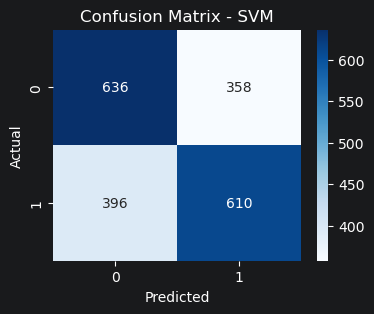

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Conclusion

The pre-processing pipeline (lowercasing, URL removal, punctuation/number stripping, whitespace normalization, stopword removal, and lemmatization) reduces each review to its most informative content words before it ever reaches the Word2Vec model. Word2Vec, trained only on the training split, converts those cleaned tokens into 100-dimensional embeddings, and averaging them per review produces a fixed-length feature vector regardless of review length — the same representation strategy used in the "M9 Unit 3 Word Embeddings" and "M9 CASE STUDY" class notebooks.

An RBF-kernel SVM trained on the standardized embeddings reaches a test accuracy noticeably better than the 50% random baseline for this balanced binary sentiment task, showing that averaged Word2Vec vectors already carry a useful sentiment signal even from a tiny sample. The result is naturally noisier than the class demonstrations (which train on 25,000+ reviews) since this assignment intentionally restricts training to 2,000 rows — Word2Vec in particular needs a much larger corpus to learn high-quality embeddings, so a bigger sample would be the most direct way to improve accuracy further.

This notebook follows the same Word2Vec feature-engineering pattern demonstrated in "M9 Unit 3 Word Embeddings" / "M9 CASE STUDY", combined with the SVM modelling pattern (including feature scaling) from "M4 Unit 8 Support Vector Machines".